# Team Intelligence and Franchise Benchmarking

While previous analyses focused on venues, innings phases, and match-level factors, this notebook evaluates franchise performance from a strategic perspective.

The objective is to benchmark IPL teams against one another and identify strengths, weaknesses, and long-term performance patterns.

The analysis focuses on consistency, chasing ability, defensive performance, and overall competitiveness.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

matches = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')

In [2]:
team_mapping = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Rising Pune Supergiant': 'Rising Pune Supergiants'
}

matches.replace(team_mapping, inplace=True)
deliveries.replace(team_mapping, inplace=True)

# Business Question 1

## Which Franchises Have Been Most Successful In IPL History?

A franchise's total victories provide a high-level indicator of long-term competitiveness and performance.

This analysis evaluates overall win totals across IPL history after standardizing franchise names.

In [3]:
team_wins = (
    matches['winner']
    .value_counts()
    .reset_index()
)

team_wins.columns = [
    'Team',
    'Wins'
]

team_wins

,Team,Wins
0,Mumbai Indians,144
1,Chennai Super Kings,138
2,Kolkata Knight Riders,131
3,Royal Challengers Bengaluru,123
4,Delhi Capitals,115
5,Rajasthan Royals,112
6,Punjab Kings,112
7,Sunrisers Hyderabad,88
8,Deccan Chargers,29
9,Gujarat Titans,28


In [4]:
team_matches = pd.concat([
    matches['team1'],
    matches['team2']
]).value_counts().reset_index()

team_matches.columns = [
    'Team',
    'Matches_Played'
]

team_matches

,Team,Matches_Played
0,Mumbai Indians,261
1,Royal Challengers Bengaluru,255
2,Delhi Capitals,252
3,Kolkata Knight Riders,251
4,Punjab Kings,246
5,Chennai Super Kings,238
6,Rajasthan Royals,221
7,Sunrisers Hyderabad,182
8,Deccan Chargers,75
9,Pune Warriors,46


In [5]:
team_summary = team_matches.merge(
    team_wins,
    on='Team',
    how='left'
)

team_summary['Wins'] = (
    team_summary['Wins']
    .fillna(0)
)

In [6]:
team_summary['Win_Percentage'] = (
    team_summary['Wins']
    /
    team_summary['Matches_Played']
    * 100
)

In [7]:
team_summary.sort_values(
    'Win_Percentage',
    ascending=False
)

,Team,Matches_Played,Wins,Win_Percentage
10,Gujarat Titans,45,28,62.222222
5,Chennai Super Kings,238,138,57.983193
0,Mumbai Indians,261,144,55.172414
11,Lucknow Super Giants,44,24,54.545455
3,Kolkata Knight Riders,251,131,52.191235
6,Rajasthan Royals,221,112,50.678733
13,Rising Pune Supergiants,30,15,50.000000
7,Sunrisers Hyderabad,182,88,48.351648
1,Royal Challengers Bengaluru,255,123,48.235294
2,Delhi Capitals,252,115,45.634921


## Reliability Consideration

Win percentages can be heavily influenced by sample size.

Newer franchises may appear at the top of rankings because they have participated in relatively few seasons.

To ensure fair comparisons, established franchises should be analyzed separately from teams with limited historical participation.

In [8]:
reliable_teams = team_summary[
    team_summary['Matches_Played'] >= 100
].sort_values(
    'Win_Percentage',
    ascending=False
)

reliable_teams

,Team,Matches_Played,Wins,Win_Percentage
5,Chennai Super Kings,238,138,57.983193
0,Mumbai Indians,261,144,55.172414
3,Kolkata Knight Riders,251,131,52.191235
6,Rajasthan Royals,221,112,50.678733
7,Sunrisers Hyderabad,182,88,48.351648
1,Royal Challengers Bengaluru,255,123,48.235294
2,Delhi Capitals,252,115,45.634921
4,Punjab Kings,246,112,45.528455


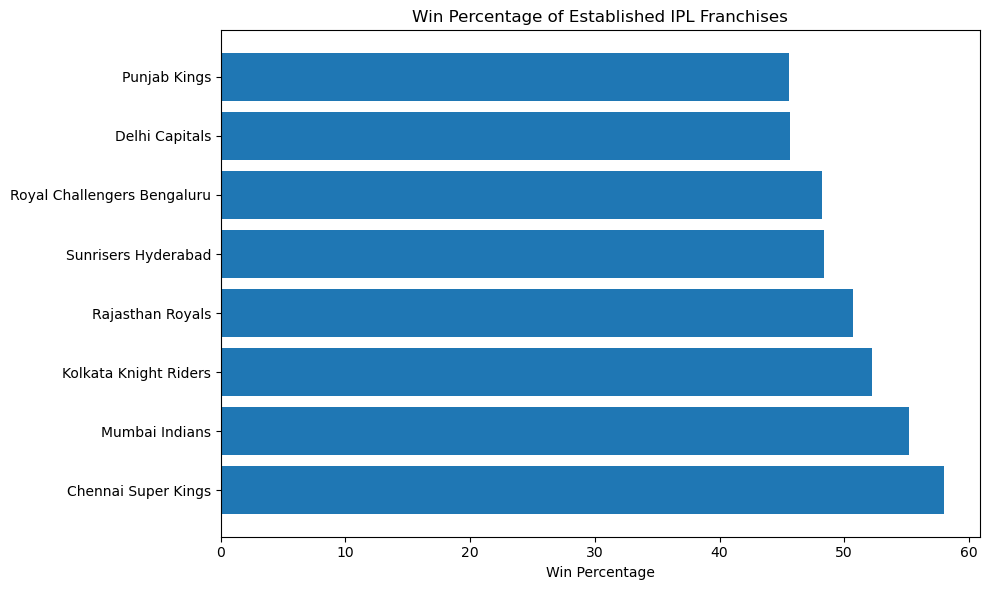

In [9]:
plt.figure(figsize=(10,6))

plt.barh(
    reliable_teams['Team'],
    reliable_teams['Win_Percentage']
)

plt.title('Win Percentage of Established IPL Franchises')
plt.xlabel('Win Percentage')

plt.tight_layout()
plt.show()

## Franchise Benchmarking

To ensure meaningful comparisons, only franchises with at least 100 matches were included in the final ranking.

This approach reduces the influence of small sample sizes and provides a more reliable view of long-term franchise performance.

## Insight

Among established IPL franchises, Chennai Super Kings recorded the highest win percentage at approximately 58%.

Mumbai Indians ranked second with a win percentage above 55%, reinforcing the long-term dominance of these two franchises throughout IPL history.

Kolkata Knight Riders and Rajasthan Royals also achieved winning records, while Royal Challengers Bengaluru, Delhi Capitals, and Punjab Kings remained below the 50% mark.

The results suggest that sustained success over multiple seasons is relatively rare, with only a small number of franchises consistently maintaining win rates above the league average.

# Business Question 2

## Which Teams Perform Best While Chasing?

Chasing has historically been a successful strategy in the IPL.

This analysis identifies franchises that have been most effective when pursuing targets and evaluates differences in chasing performance across teams.

In [10]:
chasing_wins = matches[
    matches['result'] == 'wickets'
]['winner'].value_counts()

In [11]:
team_chasing = pd.DataFrame(
    chasing_wins
).reset_index()

team_chasing.columns = [
    'Team',
    'Chasing_Wins'
]

team_chasing

,Team,Chasing_Wins
0,Kolkata Knight Riders,76
1,Mumbai Indians,71
2,Rajasthan Royals,67
3,Chennai Super Kings,67
4,Delhi Capitals,66
5,Royal Challengers Bengaluru,64
6,Punjab Kings,58
7,Sunrisers Hyderabad,43
8,Gujarat Titans,17
9,Gujarat Lions,12


In [12]:
team_chasing = team_chasing.merge(
    team_wins,
    on='Team',
    how='left'
)

team_chasing

,Team,Chasing_Wins,Wins
0,Kolkata Knight Riders,76,131
1,Mumbai Indians,71,144
2,Rajasthan Royals,67,112
3,Chennai Super Kings,67,138
4,Delhi Capitals,66,115
5,Royal Challengers Bengaluru,64,123
6,Punjab Kings,58,112
7,Sunrisers Hyderabad,43,88
8,Gujarat Titans,17,28
9,Gujarat Lions,12,13


In [13]:
team_chasing['Chasing_Win_Share'] = (
    team_chasing['Chasing_Wins']
    /
    team_chasing['Wins']
    * 100
)

In [14]:
team_chasing.sort_values(
    'Chasing_Win_Share',
    ascending=False
)

,Team,Chasing_Wins,Wins,Chasing_Win_Share
9,Gujarat Lions,12,13,92.307692
14,Kochi Tuskers Kerala,4,6,66.666667
8,Gujarat Titans,17,28,60.714286
2,Rajasthan Royals,67,112,59.821429
0,Kolkata Knight Riders,76,131,58.015267
4,Delhi Capitals,66,115,57.391304
11,Rising Pune Supergiants,8,15,53.333333
5,Royal Challengers Bengaluru,64,123,52.032520
6,Punjab Kings,58,112,51.785714
13,Pune Warriors,6,12,50.000000


## Reliability Consideration

Some franchises have participated in only a limited number of IPL seasons.

To avoid drawing conclusions from small sample sizes, chasing performance should be evaluated primarily among established franchises with substantial historical records.

In [15]:
reliable_chasing = team_chasing.merge(
    team_matches,
    on='Team',
    how='left'
)

reliable_chasing = reliable_chasing[
    reliable_chasing['Matches_Played'] >= 100
].sort_values(
    'Chasing_Win_Share',
    ascending=False
)

reliable_chasing

,Team,Chasing_Wins,Wins,Chasing_Win_Share,Matches_Played
2,Rajasthan Royals,67,112,59.821429,221
0,Kolkata Knight Riders,76,131,58.015267,251
4,Delhi Capitals,66,115,57.391304,252
5,Royal Challengers Bengaluru,64,123,52.032520,255
6,Punjab Kings,58,112,51.785714,246
1,Mumbai Indians,71,144,49.305556,261
7,Sunrisers Hyderabad,43,88,48.863636,182
3,Chennai Super Kings,67,138,48.550725,238


## Chasing Performance Benchmark

To improve reliability, chasing performance was evaluated only for franchises with at least 100 matches.

The analysis measures the proportion of a team's total victories that were achieved while chasing a target.

## Insight

Among established IPL franchises, Rajasthan Royals recorded the highest proportion of victories while chasing, with nearly 60% of their wins coming in run chases.

Kolkata Knight Riders and Delhi Capitals also demonstrated strong chasing profiles, with more than 57% of their victories achieved while pursuing targets.

In contrast, Chennai Super Kings and Sunrisers Hyderabad recorded lower chasing-win shares, suggesting a more balanced distribution between chasing victories and successful defenses.

The results indicate that franchises adopt different strategic identities, with some teams historically achieving greater success through chasing while others perform effectively in multiple match situations.

# Business Question 3

## Which Teams Defend Totals Most Effectively?

While some franchises excel during run chases, others achieve success by defending first-innings totals.

This analysis identifies teams that have historically converted batting-first opportunities into victories more effectively than their competitors.

In [17]:
defending_wins = matches[
    matches['result'] == 'runs'
]['winner'].value_counts()

In [18]:
team_defending = pd.DataFrame(
    defending_wins
).reset_index()

team_defending.columns = [
    'Team',
    'Defending_Wins'
]

team_defending

,Team,Defending_Wins
0,Chennai Super Kings,71
1,Mumbai Indians,71
2,Royal Challengers Bengaluru,57
3,Kolkata Knight Riders,54
4,Punjab Kings,51
5,Delhi Capitals,46
6,Sunrisers Hyderabad,44
7,Rajasthan Royals,43
8,Deccan Chargers,18
9,Lucknow Super Giants,16


In [19]:
team_defending = team_defending.merge(
    team_wins,
    on='Team',
    how='left'
)

team_defending

,Team,Defending_Wins,Wins
0,Chennai Super Kings,71,138
1,Mumbai Indians,71,144
2,Royal Challengers Bengaluru,57,123
3,Kolkata Knight Riders,54,131
4,Punjab Kings,51,112
5,Delhi Capitals,46,115
6,Sunrisers Hyderabad,44,88
7,Rajasthan Royals,43,112
8,Deccan Chargers,18,29
9,Lucknow Super Giants,16,24


In [20]:
team_defending['Defending_Win_Share'] = (
    team_defending['Defending_Wins']
    /
    team_defending['Wins']
    * 100
)

In [21]:
reliable_defending = team_defending.merge(
    team_matches,
    on='Team',
    how='left'
)

reliable_defending = reliable_defending[
    reliable_defending['Matches_Played'] >= 100
].sort_values(
    'Defending_Win_Share',
    ascending=False
)

reliable_defending

,Team,Defending_Wins,Wins,Defending_Win_Share,Matches_Played
0,Chennai Super Kings,71,138,51.449275,238
6,Sunrisers Hyderabad,44,88,50.000000,182
1,Mumbai Indians,71,144,49.305556,261
2,Royal Challengers Bengaluru,57,123,46.341463,255
4,Punjab Kings,51,112,45.535714,246
3,Kolkata Knight Riders,54,131,41.221374,251
5,Delhi Capitals,46,115,40.000000,252
7,Rajasthan Royals,43,112,38.392857,221


## Defensive Performance Benchmark

Defending-win share measures the proportion of a team's victories that were achieved while successfully defending a first-innings total.

Comparing defending and chasing profiles helps identify differences in franchise strategy and performance characteristics.

## Insight

Chennai Super Kings recorded the highest defending-win share among established IPL franchises, with more than 51% of their victories coming while defending totals.

Sunrisers Hyderabad and Mumbai Indians also demonstrated strong defensive profiles, suggesting consistent success when batting first.

In contrast, Rajasthan Royals recorded the lowest defending-win share among established franchises, which aligns with earlier findings showing their strong preference for chasing victories.

The results indicate that franchises can achieve success through different pathways. Some teams appear more comfortable defending totals, while others derive a larger proportion of their success from chasing targets.

# Business Question 4

## Which Teams Have Been The Most Consistent Across IPL Seasons?

Long-term success depends not only on winning matches but also on maintaining competitive performance across multiple seasons.

This analysis evaluates franchise consistency by examining average wins per season.

In [22]:
matches['season'].unique()

array(['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014',
       '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022',
       '2023', '2024'], dtype=object)

In [23]:
matches['date'] = pd.to_datetime(
    matches['date']
)

matches['analysis_year'] = (
    matches['date'].dt.year
)

In [24]:
season_wins = (
    matches[
        matches['winner'].notna()
    ]
    .groupby(
        ['analysis_year', 'winner']
    )
    .size()
    .reset_index(
        name='Wins'
    )
)

season_wins.head()

,analysis_year,winner,Wins
0,2008,Chennai Super Kings,9
1,2008,Deccan Chargers,2
2,2008,Delhi Capitals,7
3,2008,Kolkata Knight Riders,6
4,2008,Mumbai Indians,7


In [25]:
team_consistency = (
    season_wins
    .groupby('winner')
    .agg(
        Avg_Wins_Per_Season=('Wins','mean'),
        Seasons_Played=('analysis_year','nunique')
    )
)

In [26]:
team_consistency = (
    team_consistency[
        team_consistency['Seasons_Played'] >= 5
    ]
    .sort_values(
        'Avg_Wins_Per_Season',
        ascending=False
    )
)

In [27]:
team_consistency

,Avg_Wins_Per_Season,Seasons_Played
winner,,
Chennai Super Kings,9.200000,15
Mumbai Indians,8.470588,17
Kolkata Knight Riders,7.705882,17
Rajasthan Royals,7.466667,15
Sunrisers Hyderabad,7.333333,12
Royal Challengers Bengaluru,7.235294,17
Delhi Capitals,6.764706,17
Punjab Kings,6.588235,17
Deccan Chargers,5.800000,5


## Measuring Franchise Consistency

Total wins can be influenced by the number of seasons a franchise has participated in.

To evaluate consistency more fairly, average wins per season were calculated for each franchise.

This metric highlights teams that consistently perform well regardless of how long they have been part of the IPL.

## Insight

Chennai Super Kings emerged as the most consistent franchise in IPL history, averaging 9.2 wins per season.

Mumbai Indians ranked second with approximately 8.5 wins per season, reinforcing the long-term dominance of these two franchises.

Kolkata Knight Riders, Rajasthan Royals, and Sunrisers Hyderabad formed the next tier of consistent performers, averaging more than seven wins per season.

The findings suggest that sustained success in the IPL has been concentrated among a small number of franchises, with Chennai Super Kings and Mumbai Indians maintaining a noticeable advantage over the rest of the league.

# Team Intelligence and Franchise Benchmarking Summary

This notebook benchmarked IPL franchises across multiple dimensions, including overall success, chasing performance, defensive performance, and long-term consistency.

## Key Findings

### Overall Franchise Performance

- Chennai Super Kings recorded the highest win percentage among established franchises.
- Mumbai Indians ranked second, followed by Kolkata Knight Riders and Rajasthan Royals.
- Only a small number of franchises maintained win percentages above 50%.

### Chasing Performance

- Rajasthan Royals achieved the highest chasing-win share among established franchises.
- Kolkata Knight Riders and Delhi Capitals also demonstrated strong chasing capabilities.
- Several franchises appear to have developed distinct strategic preferences for pursuing targets.

### Defensive Performance

- Chennai Super Kings recorded the highest defending-win share.
- Sunrisers Hyderabad and Mumbai Indians also demonstrated strong defensive profiles.
- Successful franchises achieved victories through different strategic approaches rather than relying on a single style of play.

### Consistency

- Chennai Super Kings averaged 9.2 wins per season, the highest in the league.
- Mumbai Indians averaged approximately 8.5 wins per season.
- These two franchises have demonstrated the strongest long-term consistency in IPL history.

## Conclusion

The analysis highlights that sustained franchise success is driven not only by total victories but also by the ability to perform consistently across seasons and adapt to different match situations.

While some teams have historically excelled while chasing, others have built success through defending totals. The most successful franchises combine tactical flexibility, consistency, and strong execution across multiple competitive scenarios.